# Практическая работа 9 (Тест)
## Тема: Разведочный анализ данных

### Настройка окружения

In [259]:
import pandas as pd
import matplotlib.pyplot as plt

Дан набор данных [user_session.csv](./user_session.csv), содержащий информацию о действиях пользователей поискового сервиса.

Набор данных содержит следующие колонки:

- **id** — идентификатор пользовательского действия. Тип данных — целое число.
- **user_id** — идентификатор пользователя. Тип данных — целое число.
- **ip** — IP-адрес пользователя. Тип данных — строка.
- **action_time** — время, когда было совершено соответствующее действие. Тип данных — момент времени.
- **action** — необработанная информация о том действии, которое было совершено. Тип данных — строка.

Выполните чтение данных и сохраните датафрейм в переменную *user_session*.

In [260]:
user_session = pd.read_csv(
    "user_session.csv", parse_dates=["action_time"]
)
user_session.head(1)

,id,user_id,ip,action_time,action
0,619,NaN,244.143.138.0,2021-01-20 18:36:32,"('id': 234676, 'action': 'search', 'time': '20..."


### Вопрос 1
Определите наличие пропусков в наборе данных. В ответе укажите кол-во пропусков в столбце **user_id**.

In [261]:
user_session["user_id"].isnull().sum()

np.int64(66371)

Выполним обработку пропущенных значений:

1. Удалим столбец **user_id**. Кол-во строк при этом не должно измениться!

In [262]:
user_session = user_session.drop(columns=["user_id"])

2. Для восстановления пропусков в колонке **action_time** мы можем воспользоваться следующей информацией: известно, что значения в колонке **action_time** должны совпадать со значениями **time**, которые хранятся внутри значений характеристики **action**. 

    *Характеристика **action** имеет следующий формат:*

    ('id': <идентификатор действия>, 'action': '<название действия>', 'time': '<момент времени>')

    *В этой строке:*

    - **<идентификатор действия>** — целое число.
    - **<название действия>** — строка.
    - **<момент времени>** — строка, соответствующая моменту времени, записанная в формате *«%Y-%m-%d %H:%M:%S»*.

Порядок действий:

1. Реализуйте функцию `parse_user_action_solution`, которая принимает строку в обозначенном выше формате, а возвращает словарь. Ключами в словаре являются строки **id**, **action** и **time**, а значениями — соответствующие ключам значения из обрабатываемой строки.

    ***Обратите внимание:*** значения в словаре должны быть приведены к соответствующим типам.

    Аргумент функции `parse_user_action_solution`:

    - **line** — строка, которую необходимо превратить в словарь.

    В результате работы функция `parse_user_action_solution` должна возвращать словарь в обозначенном формате.

In [263]:
from typing import TypedDict


class UserAction(TypedDict):
    id: int
    action: str
    time: str


def parse_user_action_solution(line: str) -> UserAction:
    fields = line.strip("()").split(", ")
    user_action: UserAction = {}

    for field in fields:
        key, value = map(lambda x: x.strip("'"), field.split(": "))
        match key:
            case "id":
                value = int(value)
            case "time":
                value = pd.to_datetime(value)

        user_action[key] = value

    return user_action

2. Добавьте в датафрейм колонку **action_parse**, применив функцию `parse_user_action_solution` к колонке **action** с помощью метода `apply()`.

In [264]:
user_session["action_parse"] = user_session["action"].apply(parse_user_action_solution)

3. Восстановите на основе значений из колонки **action_parse** отсутствующую информацию о моментах времени, когда пользователи совершали соответствующие действия.

In [265]:
no_action_time = user_session["action_time"].isnull()

user_session.loc[no_action_time, "action_time"] = user_session.loc[
    no_action_time, "action_parse"
].apply(lambda x: x.get("time"))

4. Выполните приведение значений колонки **action_time** к типу *datetime* с помощью функции `pd.to_datetime`.

In [266]:
user_session["action_time"] = pd.to_datetime(user_session["action_time"])

### Вопрос 2
В качестве ответа укажите число пользовательских действий, которые были совершены в октябре 2023 года, рассчитанное по таблице с восстановленными данными.

In [267]:
october_actions = user_session[
    (user_session["action_time"].dt.year == 2023)
    & (user_session["action_time"].dt.month == 10)
]

len(october_actions)

11261

### Вопрос 3
Визуализируйте распределение пользовательских действий во времени с помощью столбчатой диаграммы. К периоду какого года относится большая часть данных?

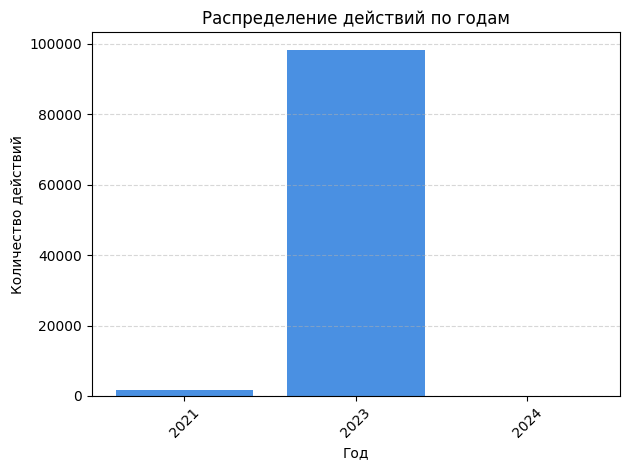

In [268]:
year_counts = user_session["action_time"].dt.year.value_counts().sort_index()

plt.bar(year_counts.index.astype(str), year_counts.values, color="#4a90e2")

plt.title("Распределение действий по годам")
plt.xlabel("Год")
plt.ylabel("Количество действий")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Вопрос 4
Сохраните в отдельную переменную данные с временем сессии до 01.01.2023 года, которые мы будем считать выбросами. Попробуем разобраться с чем может быть связано получение таких нетипичных данных и выведем все уникальные ip-адреса. В ответе укажите единственный ip-адрес, который был получен.

In [269]:
outliers = user_session[user_session["action_time"] < "2023-01-01"]

print("Уникальные IP-адреса выбросов:")
for ip in outliers["ip"].unique():
    print(ip)

Уникальные IP-адреса выбросов:
244.143.138.0


### Вопрос 5
Укажите кол-во строк, оставшихся после удаления выбросов (оставлены данные с 01.01.2023 года включительно).

Обратите внимание, что все следующие задания выполняются с предобработанным датафреймом, который мы назовем *user_session_prepr*.

In [270]:
user_session_prepr = user_session[user_session["action_time"] >= "2023-01-01"]

len(user_session_prepr)

98422

### Вопрос 6
Постройте гистограмму распределения активности пользователей с 12 интервалами. Выберите месяцы 2023 года, когда кол-во пользовательских сессий было от 6000.

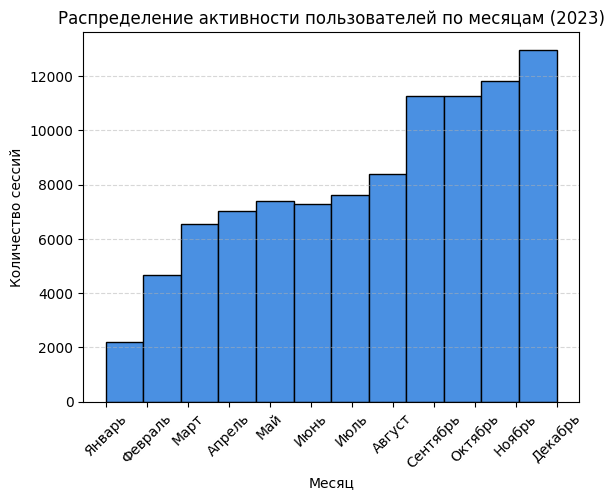

Месяцы с более чем 6000 сессиями:
3. Март
4. Апрель
5. Май
6. Июнь
7. Июль
8. Август
9. Сентябрь
10. Октябрь
11. Ноябрь
12. Декабрь


In [271]:
monthly_2023_actions = user_session_prepr["action_time"].dt.month

plt.hist(monthly_2023_actions, bins=12, edgecolor="black", color="#4a90e2")

plt.title("Распределение активности пользователей по месяцам (2023)")
plt.xlabel("Месяц")
plt.ylabel("Количество сессий")

month_names = {
    1: "Январь",
    2: "Февраль",
    3: "Март",
    4: "Апрель",
    5: "Май",
    6: "Июнь",
    7: "Июль",
    8: "Август",
    9: "Сентябрь",
    10: "Октябрь",
    11: "Ноябрь",
    12: "Декабрь",
}

plt.xticks(range(1, 13), [month_names[i] for i in range(1, 13)], rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

monthly_counts = monthly_2023_actions.value_counts().sort_index()
active_months = monthly_counts[monthly_counts >= 6000]

print("Месяцы с более чем 6000 сессиями:")
for i in active_months.index:
    print(f"{i}. {month_names[i]}")

### Вопрос 7
Для каждого ip-адреса посчитайте кол-во совершенных действий. Укажите кол-во действий для ip-адреса 200.76.176.89.

In [272]:
user_session_by_ip = user_session_prepr.groupby("ip").size()

user_session_by_ip["200.76.176.89"]

np.int64(1)

### Вопрос 8
Постройте диаграмму размаха кол-ва пользовательских действий (сгруппированные данные предыдущего задания). Рассчитайте верхнюю границу ящика с усами ($q3 + 1.5 \cdot iqr$).

Верхняя граница ящика с усами: 26.0


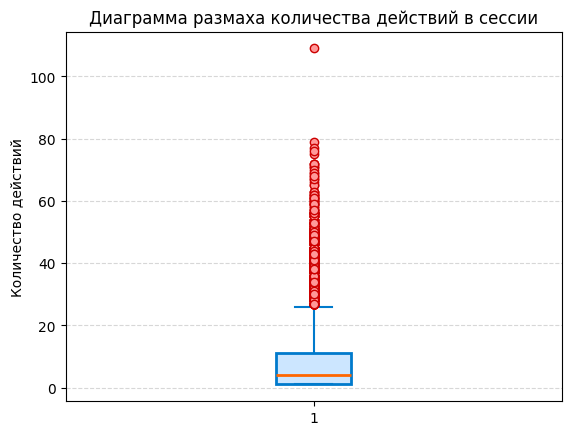

In [273]:
boxprops = dict(linewidth=2, color="#007acc", facecolor="#cce6ff")
medianprops = dict(linewidth=2, color="#ff6600")
whiskerprops = dict(linewidth=1.5, color="#007acc")
capprops = dict(linewidth=1.5, color="#007acc")
flierprops = dict(
    marker="o",
    markerfacecolor="#ff9999",
    markersize=6,
    linestyle="none",
    markeredgecolor="#cc0000",
)

plt.boxplot(
    user_session_by_ip,
    patch_artist=True,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
    flierprops=flierprops,
)


q1, q3 = user_session_by_ip.quantile([0.25, 0.75])
iqr = q3 - q1
active_upper_bound = q3 + 1.5 * iqr

print(f"Верхняя граница ящика с усами: {active_upper_bound}")

plt.title("Диаграмма размаха количества действий в сессии")
plt.ylabel("Количество действий")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Вопрос 9
Сохраните в переменную *ip_outliers* ip-адреса пользователей, которые совершили больше действий, чем рассчитанное в предыдущем задании верхнее значение. Отберите из датафрейма *user_session_prepr* те сессии пользователей, которые были совершены с ip-адресов, хранящихся в переменной *ip_outliers*. После этого постройте гистограмму распределения времени пользовательских действий в таких сессиях (с 12 колонками) и сделайте вывод, можно ли считать их выбросами?

В ответе укажите долю таких сессий к общему числу сессий, округленную до 2 знаков после запятой (Например, 0,11).

Доля сессий-выбросов: 0.35


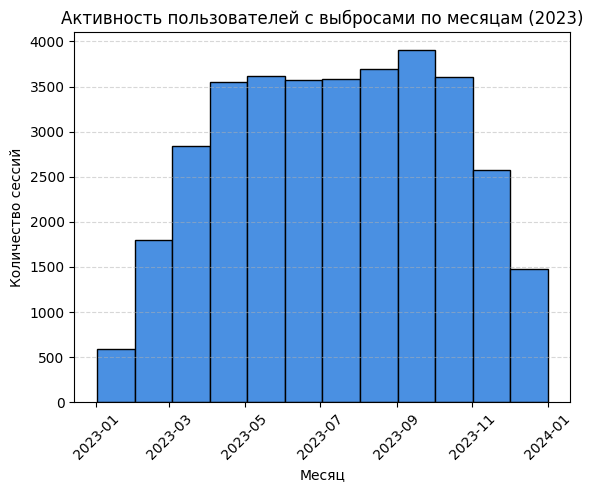

In [274]:
ip_outliers = user_session_by_ip[user_session_by_ip > active_upper_bound].index.tolist()

outlier_sessions = user_session_prepr[user_session_prepr["ip"].isin(ip_outliers)]

total_sessions = len(user_session_prepr)
outlier_sessions_count = len(outlier_sessions)
outlier_ratio = round(outlier_sessions_count / total_sessions, 2)

print(f"Доля сессий-выбросов: {outlier_ratio}")

plt.hist(outlier_sessions["action_time"], bins=12, edgecolor="black", color="#4a90e2")

plt.title("Активность пользователей с выбросами по месяцам (2023)")
plt.xlabel("Месяц")
plt.ylabel("Количество сессий")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Таким образом, метрика кол-во действий, которые совершил пользователь, не подошла для определения выбросов.

В качестве новой метрики для определения выбросов попробуем взять длину пользовательской сессии, которую можно считать, например, по числу действий или как разность между концом последнего действия и первого.

Например, у нас есть пользователь с ip-адресом 127.0.0.1, который совершил действия $t_1, t_2, t_3, t_4, t_5, t_6$:

| Пользователь | Действия                     |
|--------------|------------------------------|
| 127.0.0.1    | $t_1, t_2, t_3, t_4, t_5, t_6$        |

Будем считать, что если разница между двумя соседними действиями $t_i$ и $t_{i+1}$ небольшая, то эти действия попали в одну пользовательскую сессию. Если же $t_{i+1} - t_i > Δ$, то одна пользовательская сессия закончилась и началась другая. Будем считать $Δ = 40$ минут.

Например, действия пользователя разобьём на 3 пользовательских сессии:

| Пользователь | Сессия | Действия       |
|--------------|--------|----------------|
| 127.0.0.1    | 1      | $t_1, t_2$        |
| 127.0.0.1    | 2      | $t_3, t_4, t_5$     |
| 127.0.0.1    | 3      | $t_6$             |

Функция для объединения пользовательских действий в сессии:

In [275]:
def get_sessions(
    action_times: list[pd.Timestamp], max_delta=40 * 60
) -> list[list[pd.Timestamp]]:
    sessions = []  # список пользовательских сессий
    cur_session = []  # текущая сессия

    prev_time = None

    for time in action_times:
        if prev_time is not None and (time - prev_time).total_seconds() > max_delta:
            sessions.append(cur_session)
            cur_session = [time]
        else:
            cur_session.append(time)

        prev_time = time

    sessions.append(cur_session)

    return sessions

Для каждого ip-адреса посчитаем те пользовательские сессии, которые с него происходили, предварительно отсортировав строки по возрастанию времени сессии и проведя группировку по ip-адресам.

In [276]:
sessions = []

for ip, group in user_session.sort_values("action_time", ascending=True).groupby("ip"):
    ip_sessions = get_sessions(group["action_time"])

    cnt = 0
    for ind, session in enumerate(ip_sessions):
        for action_time in session:
            sessions.append([group.iloc[cnt]["id"], ind])
            cnt += 1

Cоздаем таблицу, где сопоставляем каждому действию пользователя номер сессии

In [277]:
sessions = pd.DataFrame(data=sessions, columns=["id", "session_ind"])

С помощью метода `merge()` выполните объединение датафреймов *user_session_prepr* и *sessions* по полю **id**. Объединенный датафрейм сохраните в переменную *user_session_ind*.

In [278]:
user_session_ind = pd.merge(user_session_prepr, sessions, on="id")

user_session_ind.head(1)

,id,ip,action_time,action,action_parse,session_ind
0,919428,157.169.233.89,2023-12-10 04:13:50,"('id': 541654, 'action': 'search', 'time': '20...","{'id': 541654, 'action': 'search', 'time': 202...",0


### Вопрос 10
Проанализировав датафрейм *user_session_ind*, укажите максимальное кол-во действий за одну сессию для пользователя с ip-адресом 17.57.136.204.

In [279]:
max_actions = (
    user_session_ind[user_session_ind["ip"] == "17.57.136.204"]
    .groupby("session_ind")
    .size()
    .max()
)

max_actions

np.int64(4)

### Вопрос 11
Для каждого ip-адреса определите максимальное кол-во действий в рамках одной пользовательской сессии. Постройте диаграмму размаха максимального кол-ва пользовательских действий. Рассчитайте и укажите в ответе верхнюю границу ящика с усами ($q3 + 1.5 \cdot iqr$).

Верхняя граница ящика с усами: 17.5


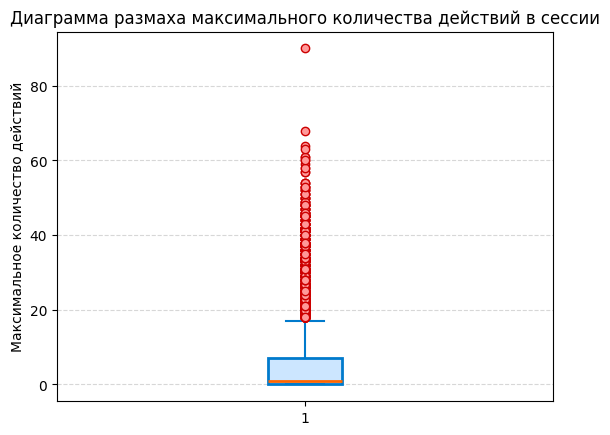

In [280]:
max_actions_per_ip = user_session_ind.groupby("ip")["session_ind"].max()

q1, q3 = max_actions_per_ip.quantile([0.25, 0.75])
iqr = q3 - q1
max_actions_upper_bound = q3 + 1.5 * iqr

print(f"Верхняя граница ящика с усами: {max_actions_upper_bound}")

plt.boxplot(
    max_actions_per_ip,
    patch_artist=True,
    boxprops=boxprops,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops,
    flierprops=flierprops,
)

plt.title("Диаграмма размаха максимального количества действий в сессии")
plt.ylabel("Максимальное количество действий")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Вопрос 12
Сфокусируемся на пользователях, у которых в максимальной пользовательской сессии было действий больше верхнего значения, которое мы определили в предыдущем задании. Сохраним в переменную *max_session_outlier_ips* их ip-адреса. В ответе укажите кол-во таких пользователей.

In [281]:
max_session_outlier_ips = max_actions_per_ip[
    max_actions_per_ip > max_actions_upper_bound
].index.tolist()

len(max_session_outlier_ips)

1318

### Вопрос 13
Отберем из датафрейма *user_session_ind* те действия, которые соответствуют пользователям *max_session_outlier_ips*. Выполним визуализацию времени активности этих пользователей (**action_time**) с помощью гистограммы и увидим, что активность таких пользователей приходится только на сентябрь-декабрь 2023 года. В самом начале нашего анализа мы с вами как раз и наблюдали "взрывную" активность в эти месяцы, когда строили график распределения времени активности:

<p align="center">
  <img src="task_13.png" alt="Гистограмма времени активности пользователей" width="600">
</p>

Поэтому мы можем считать пользователей с этими ip-адресами причиной резкого роста активности в последние месяцы 2023 года. Возможно, это вызвано работой поисковых роботов.

Выполните исключение пользователей с данными ip-адресами и сохраните результат в датафрейм *user_session_ind_no_outliers*. В качестве ответа укажите кол-во пользовательских кликов (колонка **action_parse** ключ *action*) в феврале 2023 года в получившемся датафрейме

In [282]:
user_session_ind_no_outliers = user_session_prepr[
    ~user_session_prepr["ip"].isin(max_session_outlier_ips)
]

february_data = user_session_ind_no_outliers[
    (user_session_ind_no_outliers["action_time"].dt.month == 2)
    & (user_session_ind_no_outliers["action_time"].dt.year == 2023)
]

february_clicks = february_data[
    february_data["action_parse"].apply(lambda x: x["action"] == "click")
]

len(february_clicks)

798

### Вопрос 14
Укажите, какие выводы можно было бы представить заказчикам по результатам проведённого исследования.

Не забудьте, что решения о развитии сервиса принимает не аналитик-исследователь, а заказчик, компетентный в этом вопросе.

*Варианты ответа:*

1. у сервиса есть лояльная аудитория, которая за год совершает большое количество различных действий;


2. система мониторинга, которая следит за поведением ботов в сервисе, работает плохо. Её нужно модифицировать;


3. рост активности никак не связан с надвигающимся сезоном праздников;


4. наблюдаемый рост активности, скорее всего, связан с действиями ботов, которые накручивают рейтинг конкретным сайтам.

*Ответ:* 3, 4